# Étape 01 — Clustering d'usage des capteurs

Ce notebook montre, PAS À PAS, comment on obtient la carte des capteurs colorés par pratique d'usage :
charger les profils déjà préparés (étape 00), attribuer un cluster à chaque capteur, puis construire
la carte interactive.

**Un seul paramètre pilote tout ce notebook : 'SOURCE_MODELE'** (section 0) :

- "reference" (par défaut) : le clustering K=4 DE RÉFÉRENCE du projet, déjà connu et vendorisé (voir
  'reference.py') - pas d'ajustement, juste une jointure. Simple, rapide, et les clusters ont déjà un
  nom (voir 'reference.CLUSTER_NAMES').
- "modele" : ajuste un nouveau modèle (K=4 "classique" sur le seul profil hebdomadaire, voir
  'modele_classique.py' - ou une recherche Optuna plus large, voir 'recherche_hyperparametres.py') si
  aucun modèle propre n'a encore été sauvegardé, sinon réutilise le dernier.

Changez CE SEUL paramètre en section 0 pour essayer l'autre chemin - tout le reste du notebook suit
automatiquement.

**Note sur cet environnement de démonstration** : ce notebook a besoin des sorties de
'00_transformation_des_donnees' ('usage_profiles.parquet', 'sensor_years.parquet') pour produire un
vrai résultat - lancez son 'pipeline.py' d'abord si elles n'existent pas encore.

## 0. Configuration

'SOURCE_MODELE' est LE paramètre de ce notebook (voir l'introduction ci-dessus) - tout le reste de la
configuration ne fait que dire où lire/écrire les fichiers.

In [1]:
import sys
from pathlib import Path

ICI = Path.cwd()
sys.path.insert(0, str(ICI))
RACINE = ICI.parents[1]

import pandas as pd
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)

# LE paramètre de ce notebook : "reference" (simple, par défaut) ou "modele" (ajuste-en un nouveau).
SOURCE_MODELE = "reference"

DOSSIER_CAPTEURS_ETAPE00 = RACINE / "data" / "donnees_valides" / "capteurs"
DOSSIER_MODELES = RACINE / "models" / "clustering_des_debits"
DOSSIER_SORTIE_CARTES = RACINE / "outputs" / "cartes"
FICHIER_REFERENCE = RACINE / "data" / "donnees_brutes" / "reference" / "station_clusters_k4_run006.csv"
ANNEE_REFERENCE = 2024  # l'année du run historique K=4 (voir reference.py)

print("SOURCE_MODELE :", SOURCE_MODELE)
print("Capteurs (étape 00) :", DOSSIER_CAPTEURS_ETAPE00)

SOURCE_MODELE : reference
Capteurs (étape 00) : C:\Users\olivi\Documents\GitHub\LEVEL-Cyclist-Risk-Estimation\VV6\data\donnees_valides\capteurs


## 1. Charger les profils et les coordonnées des capteurs

Les profils ('usage_profiles.parquet', une ligne par (capteur, année)) et les coordonnées
('sensor_years.parquet', qui a aussi 'lat'/'long'/'nom_site'/'code_dept') viennent tous les deux de
l'étape 00 - rien à recalculer ici. On se restreint à UNE année (2024, celle du run de référence) :
funFEM classe des capteurs, pas des (capteur, année).

In [2]:
profils_toutes_annees = pd.read_parquet(DOSSIER_CAPTEURS_ETAPE00 / "usage_profiles.parquet")
profils = profils_toutes_annees[profils_toutes_annees["annee"] == ANNEE_REFERENCE].reset_index(drop=True)

sensor_years = pd.read_parquet(DOSSIER_CAPTEURS_ETAPE00 / "sensor_years.parquet")
coordonnees = sensor_years.drop_duplicates("id_site")[["id_site", "nom_site", "lat", "long", "code_dept"]]

print(f"{len(profils):,} capteurs avec un profil {ANNEE_REFERENCE}")
profils[["id_site", "d00", "d12", "h084", "y25", "s4"]].head(5)

1,710 capteurs avec un profil 2024


,id_site,d00,d12,h084,y25,s4
0,200000071,0.000000,0.000000,0.000000,0.000000,-0.000000
1,200000082,0.010929,7.196721,8.557692,3.583333,4.931760
2,200000083,0.286885,32.210383,34.730769,28.863095,4.207988
3,200000084,1.475410,48.693989,54.038462,32.934524,4.124218
4,200000085,0.101093,14.390710,15.307692,9.654762,4.398426


## 2. La représentation multi-échelle — ['representation.py'](representation.py)

'representation_multiechelle()' transforme les colonnes de profil brutes en '(X, W)', ce que funFEM
reçoit réellement (voir sa docstring pour l'explication complète). Juste un aperçu ici - c'est
'modele_classique.py'/'recherche_hyperparametres.py' qui l'appellent pour de vrai quand
'SOURCE_MODELE = "modele"' (section 4).

In [3]:
from representation import hyperparametres_par_defaut, representation_multiechelle

hp_defaut = hyperparametres_par_defaut()
X, W = representation_multiechelle(profils, **hp_defaut)
print("hyperparamètres par défaut :", hp_defaut)
print("X :", X.shape, " (un capteur par ligne, un coefficient par colonne)")
print("W :", W.shape, " (la métrique - diagonale par blocs, un bloc par échelle de temps)")

hyperparamètres par défaut : {'n_base_jour': 12, 'n_base_semaine': 18, 'n_base_annee': 6, 'poids_jour': 1.25, 'poids_semaine': 2.5, 'poids_annee': 1.5, 'poids_spectral': 0.75}
X : (1710, 41)  (un capteur par ligne, un coefficient par colonne)
W : (41, 41)  (la métrique - diagonale par blocs, un bloc par échelle de temps)


## 3. Attribuer un cluster à chaque capteur

Selon 'SOURCE_MODELE' (section 0) :

- "reference" : une simple jointure sur le clustering déjà connu ('reference.assigner_clusters_reference'
  - voir sa docstring, notamment sa limite : ne couvre que les capteurs actifs à l'année du run).
- "modele" : on regarde d'abord si un modèle a déjà été sauvegardé sous 'models/clustering_des_debits/'
  (pas besoin de le refaire à chaque fois) ; sinon on en ajuste un - le modèle "classique" par défaut
  (K=4, profil hebdomadaire seul, voir 'modele_classique.py'), rapide et sans réglage.

In [4]:
if SOURCE_MODELE == "reference":
    from reference import CLUSTER_COULEURS, CLUSTER_NAMES, assigner_clusters_reference

    assignation = assigner_clusters_reference(profils, FICHIER_REFERENCE)
    couleurs, noms_clusters = CLUSTER_COULEURS, CLUSTER_NAMES

elif SOURCE_MODELE == "modele":
    from appliquer_modele import assigner_clusters, sauvegarder_modele

    modeles_existants = sorted(DOSSIER_MODELES.glob("01_*"))
    if modeles_existants:
        modele_dir = modeles_existants[-1]
        print(f"modèle déjà sauvegardé réutilisé : {modele_dir.name}")
    else:
        print("aucun modèle sauvegardé : ajustement du modèle classique (K=4, profil hebdomadaire seul).")
        from modele_classique import ajuster_modele_classique, config_modele_classique

        modele_funfem, graine_retenue = ajuster_modele_classique(profils, k=4, modele="AkBk", critere="bic")
        config = config_modele_classique(modele_funfem, graine_retenue, k=4, modele="AkBk", critere="bic", n_base_semaine=18)
        modele_dir = DOSSIER_MODELES / "01_classique_hebdomadaire_K4_AkBk"
        sauvegarder_modele(modele_dir, modele_funfem, config, profils, donnees_capteurs=coordonnees)

    assignation = assigner_clusters(profils, modele_dir)
    couleurs, noms_clusters = None, None  # inconnus pour un modèle fraîchement ajusté - à choisir après avoir regardé les profils (section 6)

else:
    raise ValueError(f"SOURCE_MODELE={SOURCE_MODELE!r} attendu parmi 'reference', 'modele'")

assignation["cluster"].value_counts().sort_index()

[reference] 1,570/1,710 capteurs avec un cluster de référence (run historique 2024)


cluster
0    188
1    533
2    496
3    353
Name: count, dtype: int64

## 4. La carte des clusters — ['carte.py'](carte.py)

'carte_capteurs()' a besoin d'UNE table avec, par capteur : les coordonnées, le cluster assigné, ET les
colonnes de profil (pour dessiner les courbes du panneau - voir 'profils.py'). On fusionne donc
'profils', 'assignation' (le cluster) et 'coordonnees' (`lat`/`long`/`nom_site`/`code_dept`) sur
'id_site'.

In [5]:
donnees_carte = profils.merge(assignation[["id_site", "cluster"]], on="id_site").merge(coordonnees, on="id_site", how="inner")

from carte import carte_capteurs

chemin_carte = carte_capteurs(
    donnees_carte,
    couleurs=couleurs,
    noms_clusters=noms_clusters,
    profil="tous",
    sortie=DOSSIER_SORTIE_CARTES / "carte_capteurs.html",
)
print("carte écrite :", chemin_carte)

[carte] écrit : C:\Users\olivi\Documents\GitHub\LEVEL-Cyclist-Risk-Estimation\VV6\outputs\cartes\carte_capteurs.html  (2542 Ko, 1,570 capteurs, 1,562 marqueurs, 4 clusters)
carte écrite : C:\Users\olivi\Documents\GitHub\LEVEL-Cyclist-Risk-Estimation\VV6\outputs\cartes\carte_capteurs.html


## 5. Écrire l'assignation "officielle"

Comme le ferait 'pipeline.py' : c'est CE fichier que les étapes suivantes du projet (classification des
communes, calcul du BKT) doivent lire.

In [6]:
DOSSIER_SORTIE = RACINE / "data" / "donnees_valides" / "clustering"
DOSSIER_SORTIE.mkdir(parents=True, exist_ok=True)
chemin_assignation = DOSSIER_SORTIE / "cluster_assignments.parquet"
assignation.to_parquet(chemin_assignation, index=False)
print("écrit :", chemin_assignation)

écrit : C:\Users\olivi\Documents\GitHub\LEVEL-Cyclist-Risk-Estimation\VV6\data\donnees_valides\clustering\cluster_assignments.parquet


## 6. Un coup d'œil aux profils moyens de chaque cluster — ['profils.py'](profils.py)

'construire_images_profils()' est la fonction que 'carte_capteurs()' appelle en interne ('save_as=True',
pour obtenir des images encodées prêtes pour le HTML) - ici on l'appelle directement avec 'save_as=False'
pour simplement AFFICHER les courbes dans le notebook (aucun fichier écrit). Utile pour choisir des
noms de cluster quand 'SOURCE_MODELE = "modele"' (la référence en a déjà, voir 'reference.CLUSTER_NAMES').

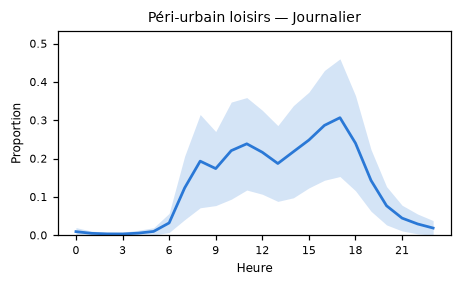

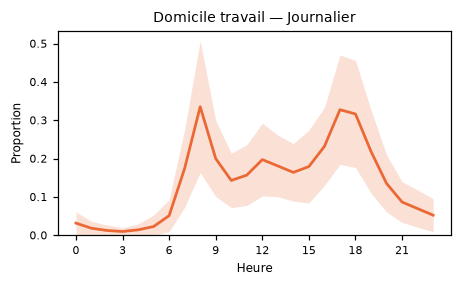

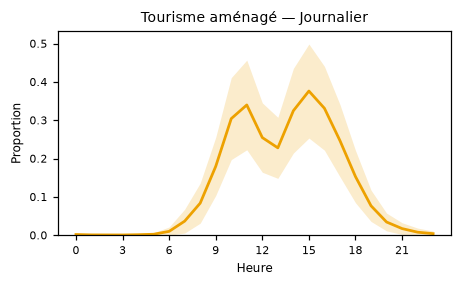

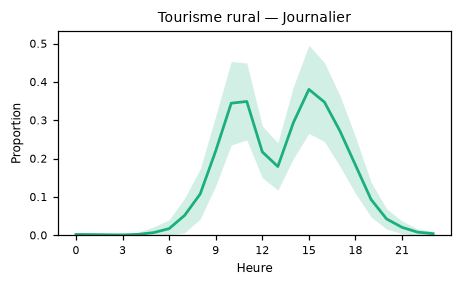

In [7]:
import matplotlib.pyplot as plt

from profils import construire_images_profils

donnees_profils = profils.merge(assignation[["id_site", "cluster"]], on="id_site")
figures = construire_images_profils(donnees_profils, profil="journalier", save_as=False, noms_clusters=noms_clusters)
for cluster, fig in figures["journalier"].items():
    plt.figure(fig.number)
plt.show()